# Bayesian Gaussian Splatting from Scratch: Turning a Point-Estimate Splat into a Distribution

*Companion notebook — W29 trend tutorial, [When Gaussians Get Uncertain: Probabilistic 3D Reconstruction](https://artifocial.com/blog/probabilistic-3d-reconstruction-2026-jul-16).*

Standard Gaussian Splatting returns **one** scene — the single configuration that best explains the training views — and says nothing about how many *other* scenes would have explained them just as well. This notebook builds the smallest honest toy that fixes that: we fit a scene, then attach a **posterior variance** to every parameter and render the resulting **confidence map**. Uncertainty comes out high where few "cameras" observed a region and collapses where many agree — exactly the behaviour last week's Gaussian Process gave us analytically.

**A deliberate honesty choice.** We use a *linear-Gaussian* observation model, for which the **Laplace approximation is exact**. That means the uncertainty you see below is not a heuristic — it is the true posterior. Real 3D Gaussian Splatting is nonlinear, so the same recipe (curvature → covariance) becomes an *approximation* there; we flag exactly where that gap opens.

Everything runs on CPU in a few seconds with only NumPy and Matplotlib.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback (works everywhere)
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
print("NumPy", np.__version__)

NumPy 2.5.1


## The Toy Scene: a 1-D Strip of Gaussians

To keep every matrix inspectable, our "scene" is a **1-D strip** of `G = 60` cells. The true scene is a sum of a few Gaussian bumps — the 1-D analogue of the anisotropic 3-D Gaussians in a real splat. Each cell holds one scalar intensity; the vector of all cell intensities is our parameter vector $\theta \in \mathbb{R}^{60}$.

In [2]:
# [Code 02] Ground-truth scene: a sum of Gaussian bumps on a 1-D strip
G = 60
x = np.arange(G)

def bump(center, width, height):
    return height * np.exp(-0.5 * ((x - center) / width) ** 2)

# NOTE: one bump (at cell 54) sits INSIDE the region no camera will observe (cells 50-58),
# so the point estimate must confidently erase a real feature there — the honest failure mode.
theta_true = bump(12, 3.5, 1.0) + bump(30, 2.0, 0.8) + bump(54, 2.5, 0.9)
print(f"Scene: {G} cells, peak intensity {theta_true.max():.2f}")

Scene: 60 cells, peak intensity 1.00


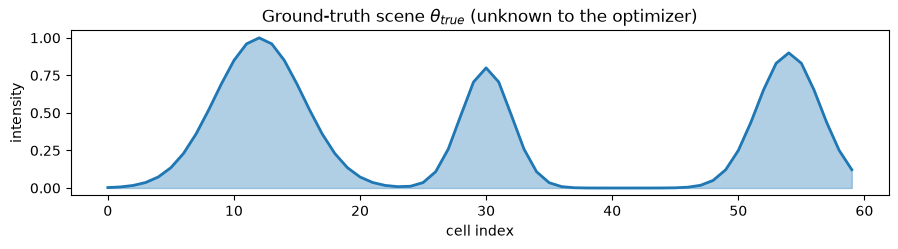

In [3]:
# [Result 01] The ground-truth scene we will try to recover
plt.figure(figsize=(9, 2.6))
plt.fill_between(x, theta_true, alpha=0.35, color="tab:blue")
plt.plot(x, theta_true, color="tab:blue", lw=2)
plt.title("Ground-truth scene $\\theta_{true}$ (unknown to the optimizer)")
plt.xlabel("cell index"); plt.ylabel("intensity"); plt.tight_layout(); plt.show()

## Cameras as Observation Operators — and Deliberately Uneven Coverage

A camera does not read cell intensities directly; it integrates them through a **ray**. We model each observation as a normalized Gaussian **footprint** over a few neighbouring cells (a soft ray), plus noise:

$$y_k = a_k^\top \theta + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma_n^2).$$

Stacking the footprints $a_k$ gives the **observation matrix** $A$, so $y = A\theta + \varepsilon$. We place cameras so coverage is **deliberately uneven**: the left third is seen by many cameras, the middle by a few, and we leave a **gap** near cells 50–58 that *no* camera observes. We place a real feature (a bump at cell 54) *inside* that gap. It is where the point estimate will confidently commit to an answer no camera constrained — here, erasing a feature that is actually there, the mirror image of the "floater" failure (same overconfidence, opposite error) — and where an honest posterior must report that it does not know.

In [4]:
# [Code 03] Build the observation matrix A from soft-ray footprints with uneven coverage
sigma_n = 0.05            # observation noise std
foot_w  = 1.2            # ray footprint width (cells)

def footprint(center):
    f = np.exp(-0.5 * ((x - center) / foot_w) ** 2)
    return f / f.sum()   # normalized: each ray integrates a local average

# Camera centers: dense on the left, sparse in the middle, NONE in the gap 50-58.
centers = (
    list(rng.uniform(4, 22, size=40)) +   # left third: heavily observed
    list(rng.uniform(24, 40, size=10)) +  # middle: lightly observed
    list(rng.uniform(41, 49, size=3))     # just before the gap
)                                          # cells ~50-58: unobserved by construction
A = np.stack([footprint(c) for c in centers])          # (num_rays, G)
y = A @ theta_true + rng.normal(0, sigma_n, size=len(centers))

coverage = A.sum(axis=0)                                # effective #rays touching each cell
print(f"{A.shape[0]} rays over {G} cells")
print(f"Coverage: max {coverage.max():.2f}, min {coverage.min():.3f} "
      f"({int((coverage < 0.05).sum())} cells effectively unobserved)")

53 rays over 60 cells
Coverage: max 3.27, min 0.000 (11 cells effectively unobserved)


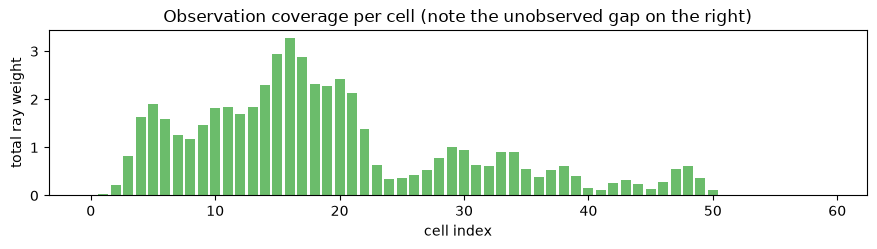

In [5]:
# [Result 02] Coverage map — how much each cell is actually observed
plt.figure(figsize=(9, 2.6))
plt.bar(x, coverage, color="tab:green", alpha=0.7)
plt.title("Observation coverage per cell (note the unobserved gap on the right)")
plt.xlabel("cell index"); plt.ylabel("total ray weight"); plt.tight_layout(); plt.show()

## The Point Estimate: One Best-Fit Scene

Standard splatting minimizes photometric loss — here, a regularized least-squares fit. With a weak Gaussian prior $\theta \sim \mathcal{N}(0, \sigma_p^2 I)$ the MAP estimate is closed-form:

$$\hat{\theta} = \left(\frac{A^\top A}{\sigma_n^2} + \frac{1}{\sigma_p^2} I\right)^{-1} \frac{A^\top y}{\sigma_n^2}$$

— exactly the precision-weighted form the code below assembles (algebraically the same as the more familiar ridge form $(A^\top A + \tfrac{\sigma_n^2}{\sigma_p^2} I)^{-1} A^\top y$). This is the notebook's stand-in for a converged splat: **a single number per cell, and no error bars.**

In [6]:
# [Code 04] MAP / regularized least-squares point estimate
sigma_p = 1.0                              # weak prior std
H = A.T @ A / sigma_n**2 + np.eye(G) / sigma_p**2   # posterior precision (Hessian of neg-log-post)
theta_hat = np.linalg.solve(H, A.T @ y / sigma_n**2)

rmse = np.sqrt(np.mean((theta_hat - theta_true) ** 2))
gap = coverage < 0.05
rmse_seen   = np.sqrt(np.mean((theta_hat[~gap] - theta_true[~gap]) ** 2))
rmse_unseen = np.sqrt(np.mean((theta_hat[gap]  - theta_true[gap])  ** 2))
print(f"RMSE overall: {rmse:.3f}")
print(f"RMSE where observed:   {rmse_seen:.3f}")
print(f"RMSE in unobserved gap: {rmse_unseen:.3f}  "
      f"({rmse_unseen/max(rmse_seen,1e-9):.1f}x worse)")

RMSE overall: 0.314
RMSE where observed:   0.221
RMSE in unobserved gap: 0.564  (2.5x worse)


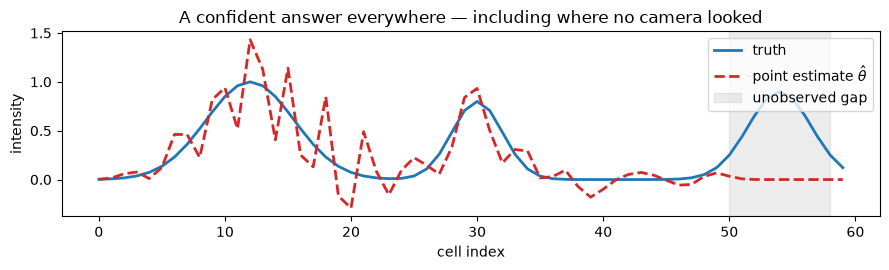

In [7]:
# [Result 03] Point estimate vs truth — accurate where observed, adrift in the gap
plt.figure(figsize=(9, 2.8))
plt.plot(x, theta_true, color="tab:blue", lw=2, label="truth")
plt.plot(x, theta_hat, color="tab:red", lw=2, ls="--", label="point estimate $\\hat{\\theta}$")
plt.axvspan(50, 58, color="grey", alpha=0.15, label="unobserved gap")
plt.title("A confident answer everywhere — including where no camera looked")
plt.xlabel("cell index"); plt.ylabel("intensity"); plt.legend(); plt.tight_layout(); plt.show()

## From Best-Fit to Posterior: the Laplace Covariance

Here is the whole move. Near the loss minimum the posterior is Gaussian,

$$p(\theta \mid y) \approx \mathcal{N}\!\left(\hat{\theta},\; H^{-1}\right), \qquad H = \frac{A^\top A}{\sigma_n^2} + \frac{1}{\sigma_p^2} I,$$

and $H$ is exactly the matrix we already built and inverted to get $\hat\theta$. **In this linear-Gaussian model the Laplace approximation is exact** — $H^{-1}$ *is* the true posterior covariance. The per-cell **posterior standard deviation** is the square root of its diagonal, and that is our confidence map.

In [8]:
# [Code 05] Posterior covariance from the same Hessian; per-cell std = confidence map
cov = np.linalg.inv(H)                 # exact posterior covariance (linear-Gaussian)
post_std = np.sqrt(np.diag(cov))       # per-cell uncertainty

std_seen   = post_std[~gap].mean()
std_unseen = post_std[gap].mean()
# Rank correlation between (lack of) coverage and uncertainty, computed from scratch.
def spearman(a, b):
    ra = np.argsort(np.argsort(a)); rb = np.argsort(np.argsort(b))
    ra = ra - ra.mean(); rb = rb - rb.mean()
    return float((ra @ rb) / (np.linalg.norm(ra) * np.linalg.norm(rb)))
rho = spearman(-coverage, post_std)    # more coverage -> less uncertainty => positive rho
print(f"Mean posterior std where observed:   {std_seen:.3f}")
print(f"Mean posterior std in unobserved gap: {std_unseen:.3f}  "
      f"({std_unseen/std_seen:.1f}x larger)")
print(f"Spearman corr (low coverage vs high uncertainty): {rho:+.2f}")
assert std_unseen > std_seen, "uncertainty must be larger where coverage is lower"

Mean posterior std where observed:   0.704
Mean posterior std in unobserved gap: 1.000  (1.4x larger)
Spearman corr (low coverage vs high uncertainty): +0.96


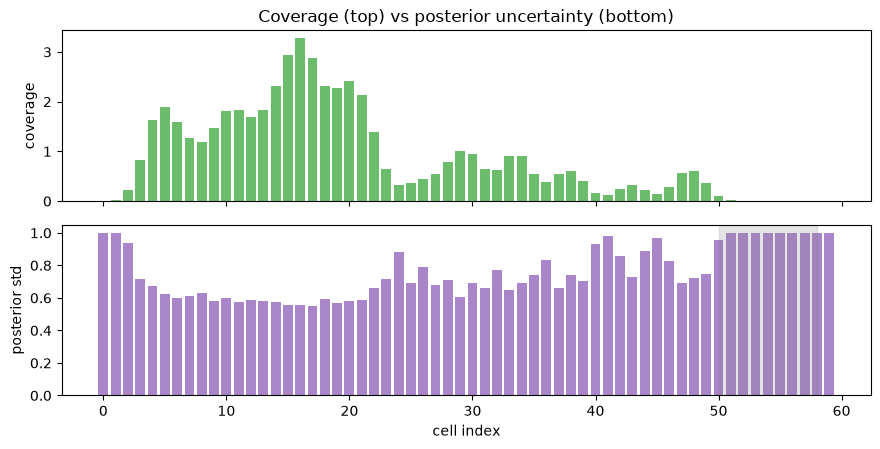

In [9]:
# [Result 04] The confidence map: uncertainty tracks the coverage gaps
fig, ax = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
ax[0].bar(x, coverage, color="tab:green", alpha=0.7)
ax[0].set_ylabel("coverage"); ax[0].set_title("Coverage (top) vs posterior uncertainty (bottom)")
ax[1].bar(x, post_std, color="tab:purple", alpha=0.8)
ax[1].axvspan(50, 58, color="grey", alpha=0.2)
ax[1].set_ylabel("posterior std"); ax[1].set_xlabel("cell index")
plt.tight_layout(); plt.show()

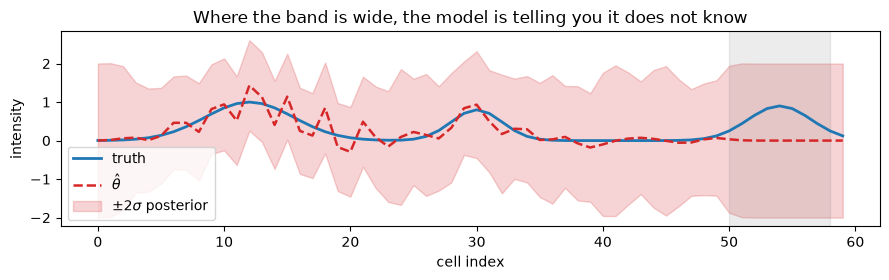

Fraction of cells with truth inside the +/-2 sigma band: 100%


In [10]:
# [Result 05] The honest render: point estimate with a +/- 2 sigma credible band
plt.figure(figsize=(9, 2.9))
plt.plot(x, theta_true, color="tab:blue", lw=2, label="truth")
plt.plot(x, theta_hat, color="tab:red", lw=1.8, ls="--", label="$\\hat{\\theta}$")
plt.fill_between(x, theta_hat - 2*post_std, theta_hat + 2*post_std,
                 color="tab:red", alpha=0.2, label="$\\pm 2\\sigma$ posterior")
plt.axvspan(50, 58, color="grey", alpha=0.15)
plt.title("Where the band is wide, the model is telling you it does not know")
plt.xlabel("cell index"); plt.ylabel("intensity"); plt.legend(); plt.tight_layout(); plt.show()

inside = np.mean(np.abs(theta_true - theta_hat) <= 2*post_std)
print(f"Fraction of cells with truth inside the +/-2 sigma band: {inside:.0%}")

### Why the variance tracks coverage — and the link back to W28

Each column of $A^\top A$ accumulates how strongly the rays constrain one cell. Well-observed cells get large diagonal entries in $H$, so small entries in $H^{-1}$ — low variance. Unobserved cells are pinned only by the weak prior, so their variance relaxes back toward $\sigma_p^2$. This is the **same behaviour as the GP posterior** from last week, where $\Sigma_* = K_{**} - K_{*X}(K_{XX}+\sigma_n^2 I)^{-1}K_{X*}$ was large in data-sparse regions and small where observations were dense. Curvature here, kernel there — both answer *"where is the data quiet?"*

**Where the honesty caveat bites.** In this linear model $H$ is constant and $H^{-1}$ is the *exact* posterior covariance. Real 3DGS rendering is **nonlinear**, so the same Laplace recipe still applies but stops being exact: $H$ must be evaluated at the optimum $\hat\theta$ and only holds locally. And where this toy has 60 cells, a real splat has *millions* of Gaussians, so even forming $H$ is infeasible — which is why practical methods lean on **diagonal or low-rank** curvature (Bayes' Rays, FisherRF, PUP 3D-GS). The *mechanism* — curvature becomes covariance — is what carries over; the exactness does not. Cheap-enough uncertainty, not exact uncertainty.

## Uncertainty That *Acts*: Choosing the Next Camera (FisherRF in Miniature)

A point estimate cannot even phrase the question *"where should I photograph next?"* A posterior can. The information a candidate camera $a_\star$ would add is captured by how much it shrinks the posterior — a one-line **expected information gain**. We score a grid of candidate viewpoints and pick the one that reduces total posterior variance the most; it should land squarely on the under-observed region.

In [11]:
# [Code 06] Expected information gain for a candidate next camera (rank-1 Sherman-Morrison update)
def variance_after_adding(center):
    a = footprint(center)
    # New precision H + a a^T / sigma_n^2; posterior var reduction via Sherman-Morrison.
    Ca = cov @ a
    denom = sigma_n**2 + a @ Ca
    cov_new_diag = np.diag(cov) - (Ca**2) / denom
    return cov_new_diag.sum()          # total posterior variance after this observation

base_total_var = np.diag(cov).sum()
candidates = np.linspace(2, 57, 56)
eig = np.array([base_total_var - variance_after_adding(c) for c in candidates])
best = candidates[int(np.argmax(eig))]
print(f"Best next camera center: cell {best:.0f} "
      f"(inside the gap 50-58: {50 <= best <= 58})")

Best next camera center: cell 57 (inside the gap 50-58: True)


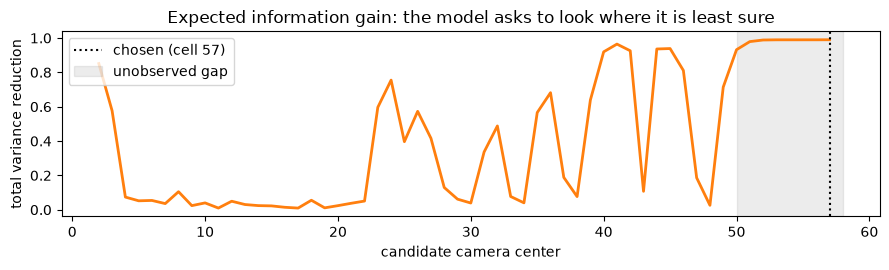

In [12]:
# [Result 06] Information gain per candidate camera — the active-capture signal
plt.figure(figsize=(9, 2.8))
plt.plot(candidates, eig, color="tab:orange", lw=2)
plt.axvline(best, color="k", ls=":", label=f"chosen (cell {best:.0f})")
plt.axvspan(50, 58, color="grey", alpha=0.15, label="unobserved gap")
plt.title("Expected information gain: the model asks to look where it is least sure")
plt.xlabel("candidate camera center"); plt.ylabel("total variance reduction")
plt.legend(); plt.tight_layout(); plt.show()

## What We Built, and What's Next

We turned a point-estimate splat into a **distribution over scenes**: one Hessian gave us both the best-fit $\hat\theta$ *and* an exact per-cell posterior variance, the variance tracked observation coverage (Spearman correlation printed above), the $\pm 2\sigma$ band was wide exactly in the unobserved gap, and the same posterior let us **choose the next camera** — the active-capture move a point estimate cannot make.

The one thing this toy cannot supply is a **prior over plausible scenes** strong enough to fill the gap with *structure* rather than a flat relaxation to the mean. That is the job of a learned **score / diffusion prior** — the subject of the companion notebook, [NB 01: Score Matching Toy](https://github.com/artifocial/tutorials/blob/main/2026-W29/01_score_matching_toy.ipynb), which shows the learned score pointing toward the data manifold — exactly where this notebook's posterior variance is low.